In [1]:
import udkm1Dsim as ud
u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

In [2]:
Fe = ud.Atom('Fe', mag_amplitude=1, mag_phi=90*u.deg, mag_gamma=90*u.deg,
             atomic_form_factor_path='./Fe.cf')
Ta = ud.Atom('Ta')
Si = ud.Atom('Si')

In [3]:
layer_Fe = ud.AmorphousLayer('Fe', 'Fe layer', 1*u.nm, 7874*u.kg/u.m**3, atom=Fe)

In [4]:
layer_Ta = ud.AmorphousLayer('Ta', 'Ta layer', thickness=1*u.nm, density=16650*u.kg/u.m**3, atom=Ta)

In [ ]:
layer_Si = ud.AmorphousLayer('Si', 'Si layer', thickness=1*u.nm, density=2650*u.kg/u.m**3, atom=Si)

In [6]:
S_sharp = ud.Structure('sharp interface')

S_sharp.add_sub_structure(layer_Ta, 10)
S_sharp.add_sub_structure(layer_Fe, 20)
S_sharp.add_sub_structure(layer_Ta, 10)
S_sharp.add_sub_structure(layer_Si, 200)

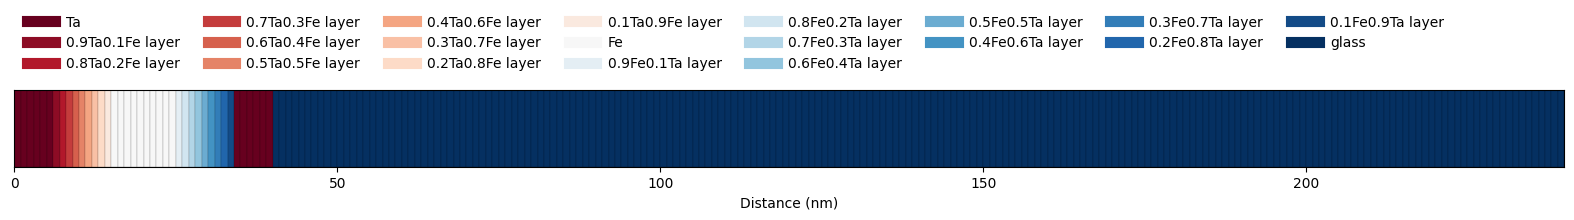

In [8]:
S_grad = ud.Structure('gradual interface')

S_grad.add_sub_structure(layer_Ta, 6)

grad_width = 9

for i in range(grad_width):
    Fe_ratio = (i+1)/(grad_width+1)
    Ta_ratio = 1-(i+1)/(grad_width+1)

    TaFe = ud.AtomMixed(f'{Ta_ratio:0.1f}Ta{Fe_ratio:0.1f}Fe')
    TaFe.add_atom(Ta, Ta_ratio)
    TaFe.add_atom(Fe, Fe_ratio)

    S_grad.add_sub_structure(
        ud.AmorphousLayer(f'{Ta_ratio:0.1f}Ta{Fe_ratio:0.1f}Fe layer',
                          f'{Ta_ratio:0.1f}Ta{Fe_ratio:0.1f}Fe layer',
                          thickness=1*u.nm,
                          density=2650*u.kg/u.m**3,
                          atom=TaFe)
                          , 1)


S_grad.add_sub_structure(layer_Fe, 10)

for i in range(grad_width):
    Ta_ratio = (i+1)/(grad_width+1)
    Fe_ratio = 1-(i+1)/(grad_width+1)

    TaFe = ud.AtomMixed(f'{Ta_ratio:0.1f}Ta{Fe_ratio:0.1f}Fe')
    TaFe.add_atom(Ta, Ta_ratio)
    TaFe.add_atom(Fe, Fe_ratio)

    S_grad.add_sub_structure(
        ud.AmorphousLayer(f'{Fe_ratio:0.1f}Fe{Ta_ratio:0.1f}Ta layer',
                          f'{Fe_ratio:0.1f}Fe{Ta_ratio:0.1f}Ta layer',
                          thickness=1*u.nm,
                          density=2650*u.kg/u.m**3,
                          atom=TaFe)
                          , 1)

S_grad.add_sub_structure(layer_Ta, 6)
S_grad.add_sub_structure(layer_Si, 200)

S_grad.visualize(cmap='RdBu')

In [9]:
dyn_mag_sharp = ud.XrayDynMag(S_sharp, True)
dyn_mag_sharp.disp_messages = True
dyn_mag_sharp.save_data = False

dyn_mag_grad = ud.XrayDynMag(S_grad, True)
dyn_mag_grad.disp_messages = True
dyn_mag_grad.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


In [10]:
dyn_mag_sharp.energy = np.r_[708]*u.eV  # set two photon energies
dyn_mag_sharp.qz = np.r_[0.01:5:0.01]/u.nm  # qz range
# this is the actual calculation
R_hom_sharp, R_hom_phi_sharp, _, _ = dyn_mag_sharp.homogeneous_reflectivity()


dyn_mag_grad.energy = np.r_[708]*u.eV  # set two photon energies
dyn_mag_grad.qz = np.r_[0.01:5:0.01]/u.nm  # qz range
# this is the actual calculation
R_hom_grad, R_hom_phi_grad, _, _ = dyn_mag_grad.homogeneous_reflectivity()

Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.087148 s
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.098286 s


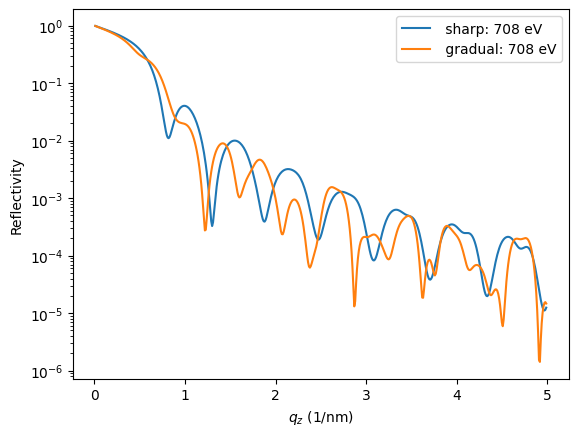

In [11]:
plt.figure()
plt.semilogy(dyn_mag_sharp.qz[0, :], R_hom_sharp[0, :], label=' sharp: {}'.format(dyn_mag_sharp.energy[0]))
plt.semilogy(dyn_mag_grad.qz[0, :], R_hom_grad[0, :], label=' gradual: {}'.format(dyn_mag_grad.energy[0]))
plt.ylabel('Reflectivity')
plt.xlabel(r'$q_z$ (1/nm)')
plt.legend()
plt.show()